In [1]:
import pandas as pd

/groups/hephy/cms/alikaan.gueven/conda/envs/SDV/lib/python3.11/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
store = pd.HDFStore('/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/plotconfig_Run2_MLscore_first/limit_tables/limit_table_store.h5', 'r')

In [3]:
import re

# Just parses the sample name.

def parse_M(name: str) -> int:
    m = re.search(r"_M(\d+)", name)
    if not m:
        raise ValueError(f"Could not parse M from: {name}")
    return int(m.group(1))

def parse_M2(name: str) -> int:
    m = re.search(r"_(\d+)_ct", name)
    if not m:
        raise ValueError(f"Could not parse M from: {name}")
    return int(m.group(1))

def parse_ct(name: str) -> float:
    m = re.search(r"ct([0-9]+(?:p[0-9]+)?)", name)
    if not m:
        return np.nan
    return float(m.group(1).replace("p", "."))

def model_group(name: str) -> str:
    if name.startswith("C1N2"):
        return "C1N2"
    if name.startswith("stop"):
        return "stop"
    return "other"

In [4]:
from copy import deepcopy
df = deepcopy(store['all_limits'])
df['M']     = df.index.map(parse_M)
df['dM']    = df['M'] - df.index.map(parse_M2)
df['ct']    = df.index.map(parse_ct)
df['model'] = df.index.map(model_group)
df

,Expected 2.5%,Expected 16.0%,Expected 50.0%,Expected 84.0%,Expected 97.5%,M,dM,ct,model
sample,,,,,,,,,
C1N2ML_M200_175_ct200_2018,0.027946,0.037791,0.054199,0.079692,0.115269,200,25,200.0,C1N2
C1N2ML_M200_175_ct20_2018,0.013092,0.017704,0.025391,0.037131,0.053726,200,25,20.0,C1N2
C1N2ML_M200_175_ct2_2018,0.015358,0.020317,0.029785,0.043082,0.061262,200,25,2.0,C1N2
C1N2ML_M200_185_ct200_2018,0.066216,0.089541,0.128418,0.188820,0.271540,200,15,200.0,C1N2
C1N2ML_M200_185_ct20_2018,0.019890,0.027188,0.038574,0.057333,0.083099,200,15,20.0,C1N2
C1N2ML_M200_185_ct2_2018,0.023415,0.031663,0.045410,0.066045,0.093904,200,15,2.0,C1N2
C1N2ML_M200_190_ct200_2018,0.062716,0.085157,0.122559,0.182158,0.264024,200,10,200.0,C1N2
C1N2ML_M200_190_ct20_2018,0.032482,0.044780,0.063965,0.095326,0.137556,200,10,20.0,C1N2
C1N2ML_M200_190_ct2_2018,0.030415,0.040799,0.058105,0.085436,0.121795,200,10,2.0,C1N2


In [5]:
obs_EXO_24_033_C1N2 = {
    'ct': (0.2, 2, 20, 200),
    'xs': (274.09, 61.364, 49.281, 133.81)
    }

obs_EXO_24_033_stop = {
    'ct': (0.2, 2, 20, 200),
    'xs': (8.499, 3.9022, 5.4943, 27.865)
    }

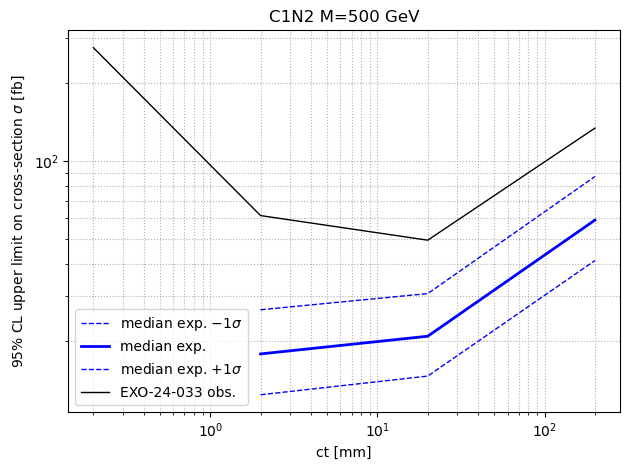

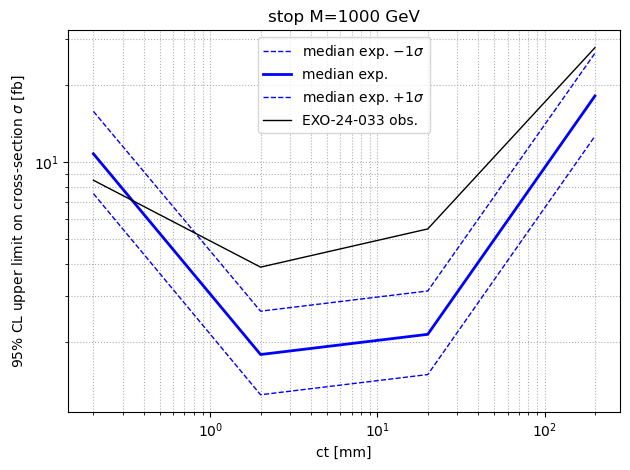

In [11]:
import matplotlib.pyplot as plt

C1N2ML_M500_xs  =  46
stopML_M1000_xs =  7.395


cols = ["Expected 16.0%", "Expected 50.0%", "Expected 84.0%"]
linestyles = ["--", "-", "--"]
labels = [r"median exp. $-1 \sigma$", r"median exp.", r"median exp. $+1 \sigma$"]

for model in ["C1N2", "stop"]:
    if model =="C1N2":
        xs = C1N2ML_M500_xs
        M = 500
        sub = df[(df["M"] == M) & (df["model"] == model) & (df["dM"] == 15)].sort_values("ct")
    elif model =="stop":
        xs = stopML_M1000_xs
        M = 1000
        sub = df[
            ((df["M"] == M) & (df["model"] == model) & (df["dM"] == 25) & (df["ct"] == 0.2)) | 
            ((df["M"] == M) & (df["model"] == model) & (df["dM"] == 20) & (df["ct"] == 2))   | 
            ((df["M"] == M) & (df["model"] == model) & (df["dM"] == 15) & (df["ct"] == 20))  | 
            ((df["M"] == M) & (df["model"] == model) & (df["dM"] == 12) & (df["ct"] == 200))
            ].sort_values("ct")
    # print(sub)
    

    plt.figure()
    for i, c in enumerate(cols):
        lw=1 if i in [0,2] else 2
        plt.plot(sub["ct"], sub[c]*xs, label=labels[i], color='blue', linestyle=linestyles[i], lw=lw)

    if model == "C1N2":
        plt.plot(obs_EXO_24_033_C1N2['ct'], obs_EXO_24_033_C1N2['xs'], color="black", lw=1, linestyle="-", label='EXO-24-033 obs.')
    elif model == "stop":
        plt.plot(obs_EXO_24_033_stop['ct'], obs_EXO_24_033_stop['xs'], color="black", lw=1, linestyle="-", label='EXO-24-033 obs.')
    
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("ct [mm]")
    plt.ylabel(r"95% CL upper limit on cross-section $\sigma$ [fb]")
    plt.title(f'{model} M={M} GeV')
    plt.grid(True, which="both", linestyle=":")
    plt.legend()
    plt.tight_layout()
plt.show()

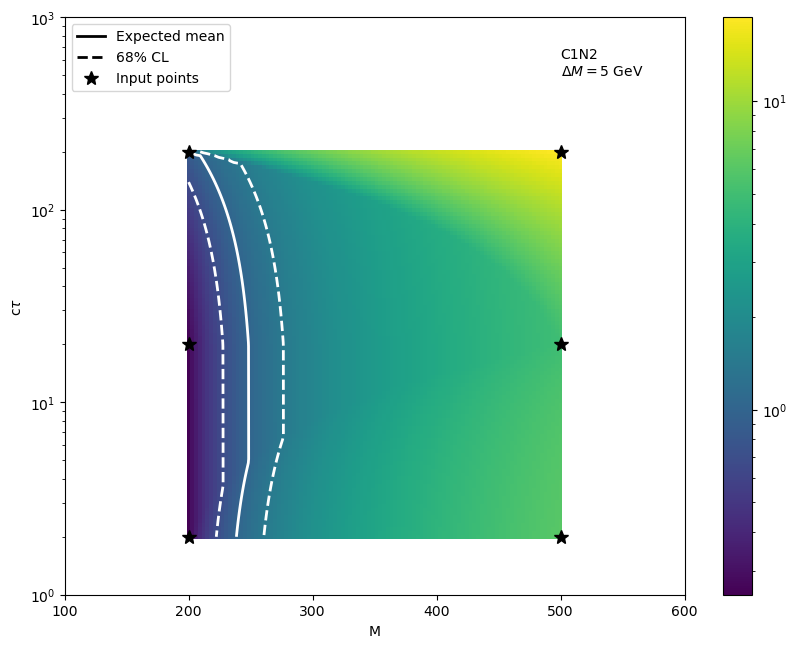

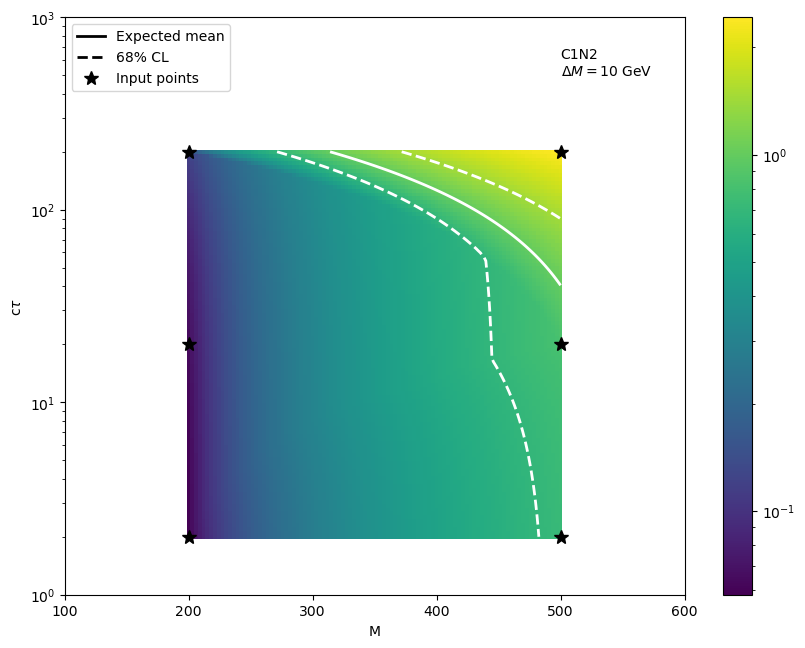

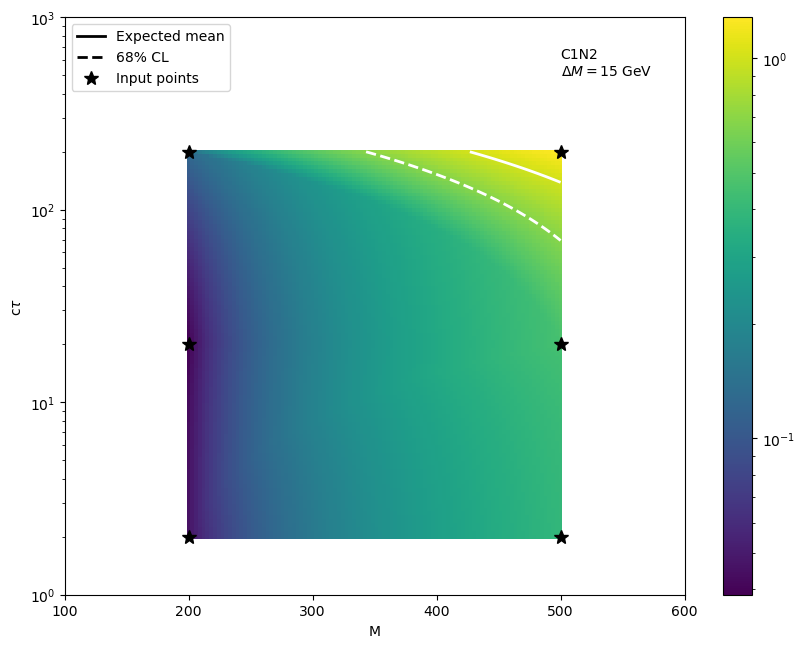

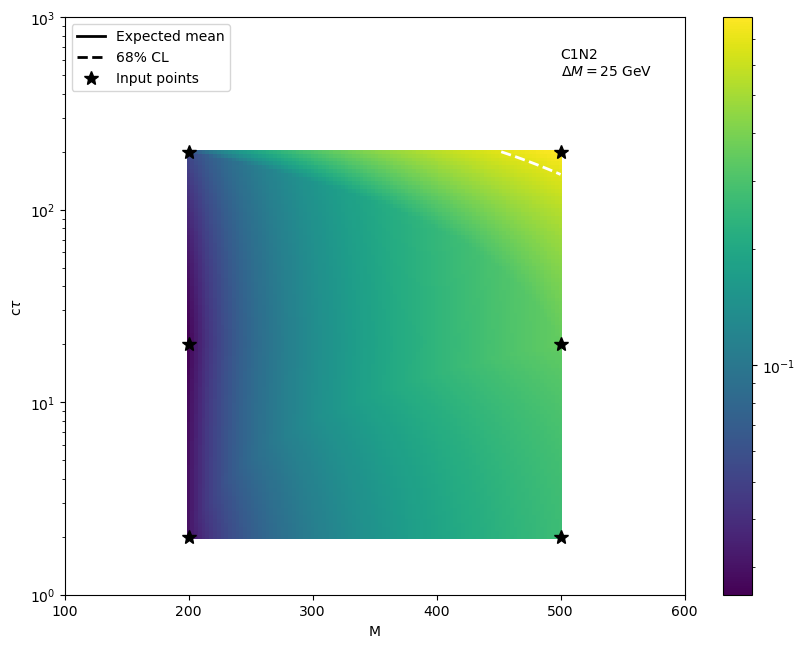

In [ ]:
# Ref: https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.LinearNDInterpolator.html#scipy.interpolate.LinearNDInterpolator

from scipy.interpolate import LinearNDInterpolator
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.pyplot as plt

for dM in [5,10,15,25]:

    # dM = 10
    model = 'C1N2'

    mask = (df['dM'] == dM) & (df['model'] == model)

    x = df.loc[mask, 'M']
    y = df.loc[mask, 'ct']
    z = df.loc[mask, 'Expected 50.0%']

    X = np.linspace(x.min(), x.max(), 100)
    Y = np.logspace(np.log10(y.min()), np.log10(y.max()), 100)
    X, Y = np.meshgrid(X, Y)

    interp = LinearNDInterpolator(list(zip(x, y)), z)
    Z = interp(X, Y)

    Z = np.ma.masked_invalid(Z)
    Z = np.ma.masked_less_equal(Z, 0)

    z16 = df.loc[mask, 'Expected 16.0%']
    z84 = df.loc[mask, 'Expected 84.0%']

    Z16 = LinearNDInterpolator(list(zip(x, y)), z16)(X, Y)
    Z84 = LinearNDInterpolator(list(zip(x, y)), z84)(X, Y)

    Z16 = np.ma.masked_invalid(Z16)
    Z16 = np.ma.masked_less_equal(Z16, 0)

    Z84 = np.ma.masked_invalid(Z84)
    Z84 = np.ma.masked_less_equal(Z84, 0)

    plt.figure(figsize=(10, 7.5))
    pcm = plt.pcolormesh(X, Y, Z, shading='auto', norm=LogNorm())

    c50 = plt.contour(X, Y, Z, levels=[1], colors='w', linewidths=2)
    c16 = plt.contour(X, Y, Z16, levels=[1], colors='w', linewidths=2, linestyles='--')
    c84 = plt.contour(X, Y, Z84, levels=[1], colors='w', linewidths=2, linestyles='--')

    pts = plt.plot(x, y, '*k', markersize=10)[0]

    plt.yscale('log')
    plt.colorbar(pcm)
    plt.xlim(100, 600)
    plt.ylim(1, 1e3)
    plt.xlabel('M')
    plt.ylabel(r'c$\tau$')
    plt.annotate(f'{model}\n$\\Delta M = {dM}$ GeV', (0.80, 0.90), xycoords='axes fraction')



    plt.legend(handles=[
        Line2D([0], [0], color='k', lw=2, label='Expected mean'),
        Line2D([0], [0], color='k', lw=2, ls='--', label='68% CL'),
        Line2D([0], [0], color='k', marker='*', lw=0, markersize=10, label='Input points'),
    ])

    plt.show()